In [1]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import VGG16

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [3]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [ ]:
base_model.trainable = False #Freeze VGG16 Layers

Why Freeze?

We keep the pretrained knowledge.

Only the new classification layers will learn.

In [6]:
#Build VGG16 Model
model_vgg16 = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

In [9]:
model_vgg16.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

TRAIN VGG16 MODEL

In [11]:
model_vgg16.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [13]:
history_vgg16 = model_vgg16.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 689s 4s/step - accuracy: 0.8468 - loss: 0.3548 - val_accuracy: 0.6250 - val_loss: 0.7885
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.9294 - loss: 0.1944 - val_accuracy: 0.6250 - val_loss: 0.7972
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 633s 4s/step - accuracy: 0.9394 - loss: 0.1614 - val_accuracy: 0.7500 - val_loss: 0.6618
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 640s 4s/step - accuracy: 0.9467 - loss: 0.1435 - val_accuracy: 0.7500 - val_loss: 0.6048
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 631s 4s/step - accuracy: 0.9555 - loss: 0.1272 - val_accuracy: 0.7500 - val_loss: 0.6062
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 628s 4s/step - accuracy: 0.9580 - loss: 0.1199 - val_accuracy: 0.7500 - val_loss: 0.5802
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 632s 4s/step - accuracy: 0.9588 - loss: 0.1143 - val_accuracy: 0.7500 - val_loss: 0.8098
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 632s 4s/step - accuracy: 0.9580 - loss: 0.1090 - val_accu

In [14]:
test_loss_vgg16, test_accuracy_vgg16 = model_vgg16.evaluate(
    test_dataset
)

print(f"Test Loss: {test_loss_vgg16:.4f}")
print(f"Test Accuracy: {test_accuracy_vgg16:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.8510 - loss: 0.4228
Test Loss: 0.4228
Test Accuracy: 0.8510


In [15]:
import numpy as np

y_true_vgg16 = []
y_pred_vgg16 = []

for images, labels in test_dataset:

    predictions = model_vgg16.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions > 0.5
    ).astype(int)

    y_true_vgg16.extend(
        labels.numpy()
    )

    y_pred_vgg16.extend(
        predictions
    )

In [16]:
y_true_vgg16 = np.array(
    y_true_vgg16
).flatten()

y_pred_vgg16 = np.array(
    y_pred_vgg16
).flatten()

print(y_true_vgg16.shape)
print(y_pred_vgg16.shape)

(624,)
(624,)


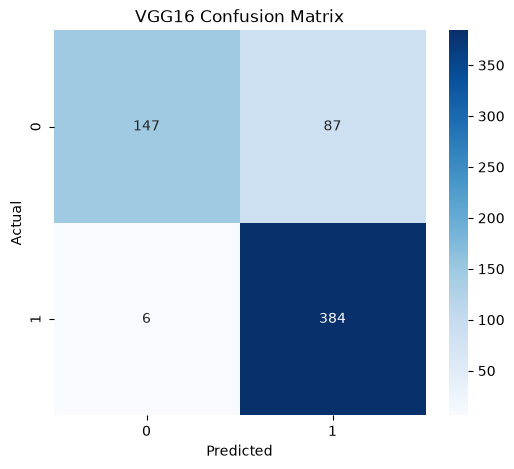

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vgg16 = confusion_matrix(
    y_true_vgg16,
    y_pred_vgg16
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_vgg16,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.show()

In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_vgg16,
        y_pred_vgg16,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.96      0.63      0.76       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



In [19]:
model_vgg16.save(
    "../models/vgg16_pneumonia.keras"
)

print("VGG16 saved successfully")

VGG16 saved successfully
